# **1. Perkenalan Dataset**


## Eksperimen Klasifikasi Topik Berita 20 Newsgroups

**Deskripsi Proyek**  
Dataset “20 Newsgroups” merupakan kumpulan sekitar 18.000 postingan newsgroups yang dibagi ke dalam 20 topik berbeda, dengan subset pelatihan (train) dan pengujian (test) dipisahkan berdasarkan tanggal posting. Proyek ini akan memanfaatkan fungsi `sklearn.datasets.fetch_20newsgroups` untuk mengunduh teks mentah, membangun pipeline ekstraksi fitur (CountVectorizer/Tf‑idf), lalu melatih dan mengevaluasi model klasifikasi multi‑kelas.

**Mengapa Topik Ini?**  
- Memberi tantangan klasifikasi 20 kelas
- Langsung tersedia di Scikit‑Learn: minimal setup, langsung CSV via notebook

**Tujuan & Metri­k**  
- **Tujuan**: Mengklasifikasikan dokumen ke salah satu dari 20 kategori topik.  
- **Metri­k Evaluasi**: Accuracy & Macro‑F1 Score untuk mengukur performa di semua kelas secara merata.

**Ringkasan Tahapan di Notebook ini**  
1. Import library Python yang diperlukan  
2. Download & simpan dataset raw ke folder `newsgroups_raw/` menggunakan `fetch_20newsgroups`  
3. Memuat dataset dari file CSV dan verifikasi struktur  
4. Exploratory Data Analysis (EDA):  
   - Cek missing values & distribusi kelas  
   - Analisis panjang dokumen dan kata paling sering  
5. Data Preprocessing:  
   - Pembersihan teks (lowercase, remove punctuation)  
   - Stopword removal  
   - Split train/test untuk persiapan modelling  

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import pandas as pd
from sklearn.datasets import fetch_20newsgroups

# visualize
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# preprocess
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

!pip install --upgrade spacy
!python -m spacy download en_core_web_sm
import spacy
nlp = spacy.load("en_core_web_sm")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 1.8 MB/s eta 0:00:0000:0100:01m
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
print(spacy.__version__)            
print("Model loaded:", nlp.meta["name"])

3.8.7
Model loaded: core_web_sm


# **3. Memuat Dataset**

In [3]:
# ensure the existence of a folder to store raw data
raw_dir = os.path.join('..', 'newsgroups_raw')
os.makedirs(raw_dir, exist_ok=True)

In [4]:
# download the entire subset (train + test) without headers/footers/quotes
data = fetch_20newsgroups(subset='all',
                          remove=('headers','footers','quotes'))

In [5]:
# create DataFrame
df = pd.DataFrame({
    'text': data.data,
    'target': data.target
})
df['target_name'] = df.target.map(lambda i: data.target_names[i])

In [6]:
# save to .csv
csv_path = os.path.join(raw_dir, '20newsgroups.csv')
df.to_csv(csv_path, index=False, encoding='utf-8')
print(f"Dataset berhasil disimpan ke: {csv_path} (total {len(df)} baris)")

Dataset berhasil disimpan ke: ../newsgroups_raw/20newsgroups.csv (total 18846 baris)


In [ ]:
csv_path = '../newsgroups_raw/20newsgroups.csv'
df = pd.read_csv(csv_path)
# display data sample
df.head()

In [7]:
# check file existence
assert os.path.exists(csv_path), "File CSV tidak ditemukan!"

# **4. Exploratory Data Analysis (EDA)**

Di tahap ini akan dilakukan:
1. Memeriksa ukuran dataset, missing values, dan duplikat  
2. Melihat distribusi kelas (20 topik)  
3. Menganalisis panjang dokumen (karakter & kata)  
4. Menampilkan kata‑kata paling sering muncul  
5. (Opsional) Cek korelasi antara panjang teks dan kelas  

In [ ]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (18846, 3)


,text,target,target_name
0,\n\nI am sure some bashers of Pens fans are pr...,10,rec.sport.hockey
1,My brother is in the market for a high-perform...,3,comp.sys.ibm.pc.hardware
2,\n\n\n\n\tFinally you said what you dream abou...,17,talk.politics.mideast
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,3,comp.sys.ibm.pc.hardware
4,1) I have an old Jasmine drive which I cann...,4,comp.sys.mac.hardware


In [9]:
print("Missing values per kolom:")
print(df.isna().sum(), "\n")

dup_count = df.duplicated().sum()
print(f"Jumlah baris duplikat: {dup_count}")

Missing values per kolom:
text           380
target           0
target_name      0
dtype: int64 

Jumlah baris duplikat: 475


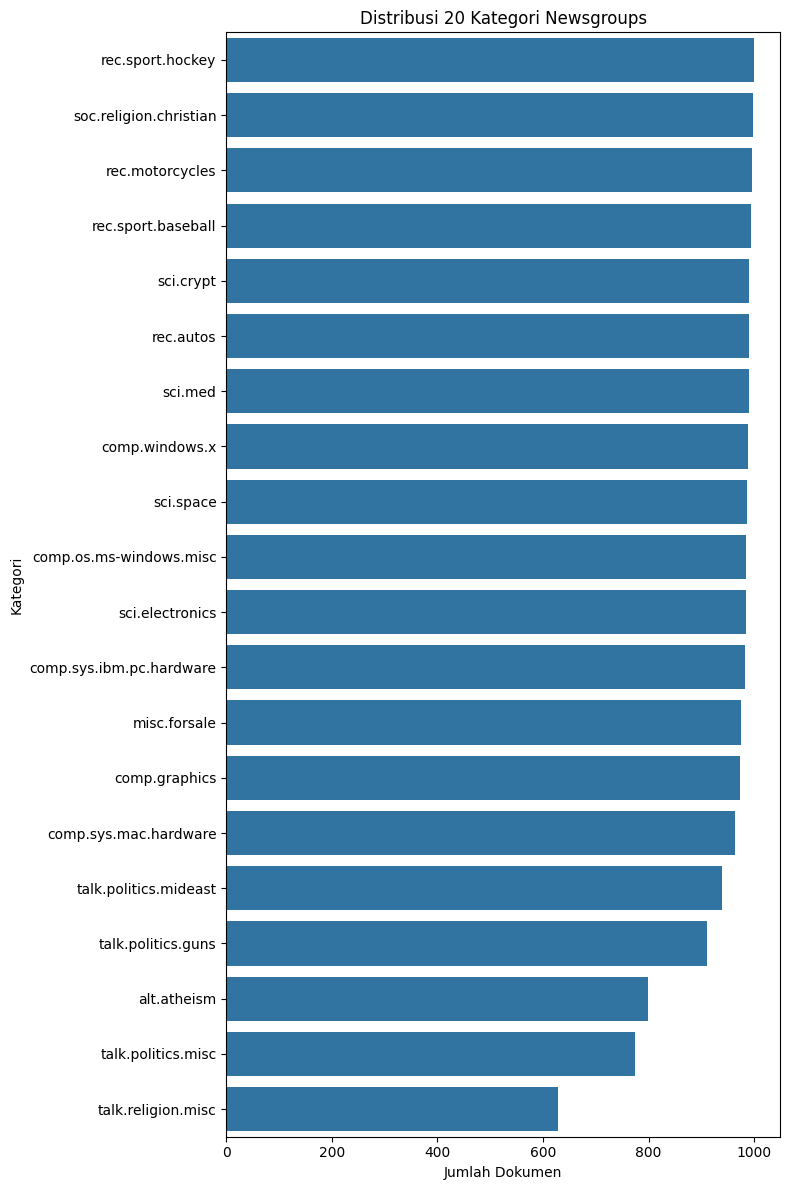

In [10]:
plt.figure(figsize=(8, 12))
sns.countplot(y='target_name', data=df,
              order=df['target_name'].value_counts().index)
plt.title('Distribusi 20 Kategori Newsgroups')
plt.xlabel('Jumlah Dokumen')
plt.ylabel('Kategori')
plt.tight_layout()
plt.show()

            char_len      word_len
count   18846.000000  18846.000000
mean     1169.667516    181.637748
std      3858.748875    501.333800
min         0.000000      0.000000
25%       234.000000     40.000000
50%       489.000000     83.000000
75%       979.000000    166.000000
max    158791.000000  11765.000000


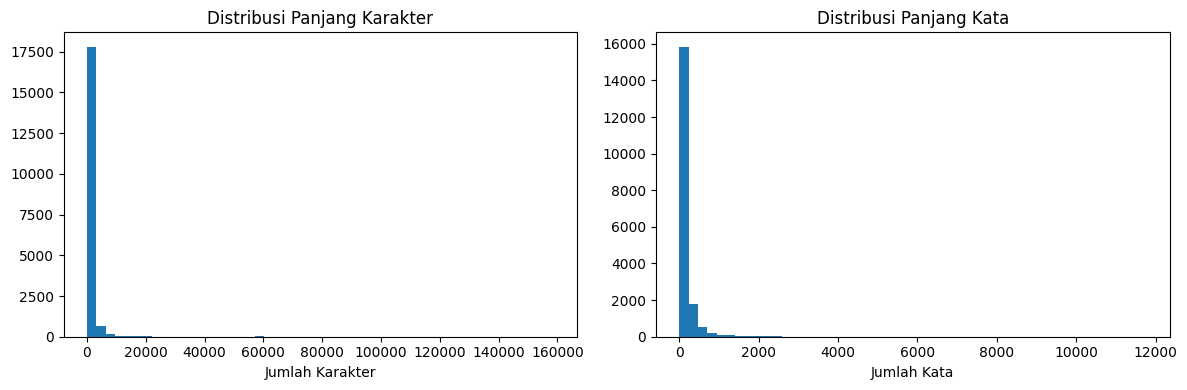

In [11]:
# analisis panjang dokumen
#   - karakter
#   - kata

# fill missing text with empty string
df['text'] = df['text'].fillna('')

# count char and word length
df['char_len'] = df['text'].str.len()
df['word_len'] = df['text'].str.split().apply(len)

# summary statistics
print(df[['char_len','word_len']].describe())

# histogram visualize
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].hist(df['char_len'], bins=50)
axes[0].set_title('Distribusi Panjang Karakter')
axes[0].set_xlabel('Jumlah Karakter')

axes[1].hist(df['word_len'], bins=50)
axes[1].set_title('Distribusi Panjang Kata')
axes[1].set_xlabel('Jumlah Kata')

plt.tight_layout()
plt.show()

     word   count
0     the  173592
1     and   70083
2    that   45942
3     for   32302
4     you   30492
5    this   23519
6    have   21322
7    with   20897
8     are   20844
9     not   20560
10    was   15872
11    but   15550
12   they   15290
13   from   13578
14    can   13115
15  there   11108
16   what   10787
17    all   10693
18   will   10534
19    one   10397


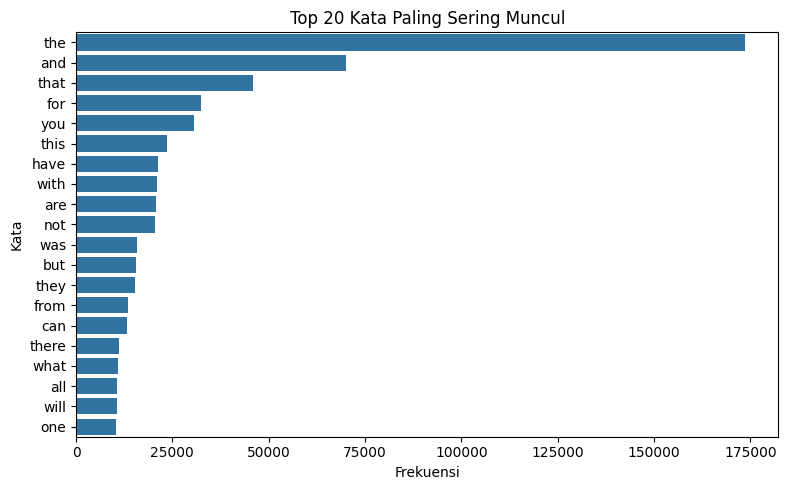

In [12]:
# kata‑kata paling sering muncul (Top 20)

# join all text, clean non-alphanumeric symbols
all_text = " ".join(df['text'])
words = re.findall(r'\b[a-zA-Z]{3,}\b', all_text.lower())

# count frequency, take top 20
common_words = Counter(words).most_common(20)
common_df = pd.DataFrame(common_words, columns=['word','count'])

# display tables and barplots
print(common_df)

plt.figure(figsize=(8,5))
sns.barplot(x='count', y='word', data=common_df)
plt.title('Top 20 Kata Paling Sering Muncul')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')
plt.tight_layout()
plt.show()


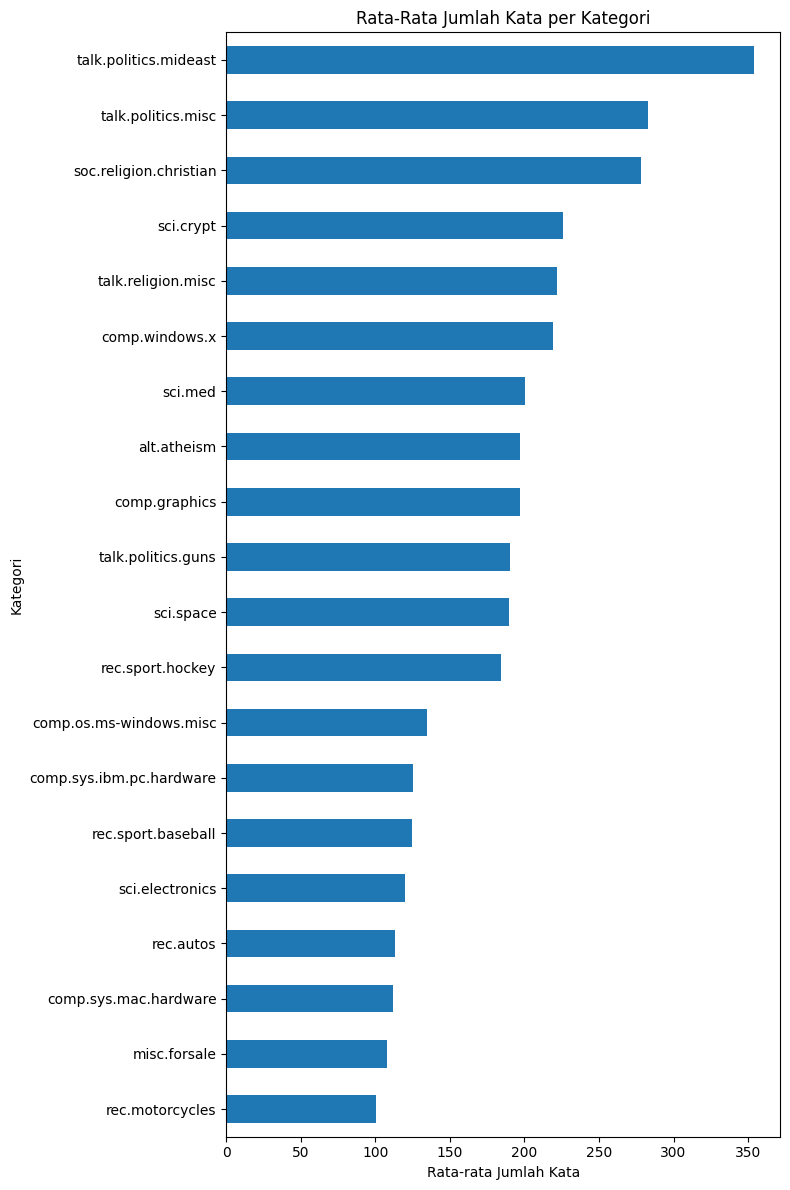

In [13]:
# panjang rata‑rata dokumen per kategori
avg_len = df.groupby('target_name')['word_len'].mean().sort_values()
avg_len.plot(kind='barh', figsize=(8,12))
plt.title('Rata‑Rata Jumlah Kata per Kategori')
plt.xlabel('Rata‑rata Jumlah Kata')
plt.ylabel('Kategori')
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini akan dilakukan pembersihan dan persiapan data teks agar siap digunakan untuk modelling. Langkah‑langkah yang kita terapkan:

1. Tangani missing values  
2. Hapus duplikat  
3. Bersihkan teks (newline, tab, HTML entities, punctuation)  
4. Lowercase & normalize whitespace  
5. Stopword removal  
6. Lemmatization dengan spaCy  
7. Simpan hasil preprocessing ke folder `newsgroups_preprocessing/`  

In [14]:
# create a preprocessing output directory if it doesn't exist already
output_dir = os.path.join('newsgroups_preprocessing')
os.makedirs(output_dir, exist_ok=True)

In [16]:
# handle missing values in the 'text' column by replacing NaN with an empty string
df['text'] = df['text'].fillna('')

In [17]:
# drop duplicate rows (based on text and label)
before = df.shape[0]
df = df.drop_duplicates(subset=['text', 'target'])
after = df.shape[0]
print(f"Baris duplikat dihapus: {before - after}")

Baris duplikat dihapus: 475


In [18]:
# text cleaning function
def clean_text(text: str) -> str:
    text = text.replace('\n', ' ').replace('\t', ' ')
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# apply cleaning
df['clean_text'] = df['text'].apply(clean_text)

In [19]:
# stopword removal
def remove_stopwords(text: str) -> str:
    tokens = text.split()
    filtered = [w for w in tokens if w not in ENGLISH_STOP_WORDS]
    return " ".join(filtered)

df['clean_text'] = df['clean_text'].apply(remove_stopwords)

In [20]:
# lemmatization with spaCy
def lemmatize(text: str) -> str:
    doc = nlp(text)
    return " ".join(token.lemma_ for token in doc)
df['clean_text'] = df['clean_text'].apply(lemmatize)

In [21]:
# handle any remaining NaN di kolom clean_text
df['clean_text'] = df['clean_text'].fillna('')
assert df['clean_text'].isna().sum() == 0, "Masih ada NaN di clean_text!"

In [22]:
# verification preprocessing result: display several samples
df.head(5)

,text,target,target_name,clean_text
0,\n\nI am sure some bashers of Pens fans are pr...,10,rec.sport.hockey,sure basher pen fan pretty confused lack kind ...
1,My brother is in the market for a high-perform...,3,comp.sys.ibm.pc.hardware,brother market high performance video card sup...
2,\n\n\n\n\tFinally you said what you dream abou...,17,talk.politics.mideast,finally say dream mediterranean new area great...
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,3,comp.sys.ibm.pc.hardware,think s scsi card do dma transfer disk scsi ca...
4,1) I have an old Jasmine drive which I cann...,4,comp.sys.mac.hardware,1 old jasmine drive use new understanding upsa...


In [23]:
# Save the preprocessing DataFrame to .csv
output_path = os.path.join(output_dir, '20newsgroups_preprocessed.csv')
df[['clean_text','target','target_name']].to_csv(output_path, index=False, encoding='utf-8')
print("Preprocessed data saved to:", output_path)
print("Setelah preprocessing:", df.shape)

Preprocessed data saved to: newsgroups_preprocessing/20newsgroups_preprocessed.csv
Setelah preprocessing: (18371, 4)
